# Credit Card Fraud Detection

 **Module**  M606 Machine Learning

 **Professor** : Mohammad Mahdavi

**Student Name** : Arun Singh Chauhan

 **Student ID** :  GH1052389

 **Dataset** : https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud

 **GitHub** : https://github.com/Arun-Singh-Chauhan-09/m606-fraud-detection-pipeline.git |



## 1. Introduction

Credit card fraud is a significant challenge for banks and financial institutions. Every day, millions of transactions occur, and a small percentage of these are fraudulent. Detecting these fraudulent transactions quickly is important to prevent financial losses.

### Why Does It Matter?
According to industry reports, global losses from credit card fraud has exceeded $33 billion in 2023. Beyond the direct financial impact, false alarms
that block legitimate transactions can damage customer trust.


### What is the Goal?
In this project, I want to build a model that can tell the difference between a genuine transaction and a fraudulent one. I will train three models — Logistic Regression, Decision Tree, and Random Forest — and compare them to find which one works best. Because the dataset is heavily imbalanced (only 0.17% of transactions are fraud), I will use F1-Score and PR-AUC to judge performance rather than simple accuracy.

## 2. Import Libraries
I have used pandas, matplotlib and scikit-learn libraries.

In [11]:

import pandas as data_processor
import matplotlib.pyplot as visualizer

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, average_precision_score)
from sklearn.utils import resample


visualizer.style.use('seaborn-v0_8')



## 3. Load and Explore Data

In [14]:
transaction_data = data_processor.read_csv('creditcard.csv')
transaction_data.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


### Check Data Types

In [15]:
data_processor.DataFrame({
    'Feature': transaction_data.dtypes.index,
    'Data Type': transaction_data.dtypes.values
})

,Feature,Data Type
0,Time,float64
1,V1,float64
2,V2,float64
3,V3,float64
4,V4,float64
5,V5,float64
6,V6,float64
7,V7,float64
8,V8,float64
9,V9,float64


All features are numeric (float64 or int64), with 'Class' as the target variable (0 = genuine, 1 = fraud).

### Check Missing Values



In [18]:

missing_count = transaction_data.isnull().sum().sum()

data_processor.DataFrame({
    'Check': ['Missing Values'],
    'Status': ['No missing values found'] if missing_count == 0 else ['Missing values detected'],
    'Count': [missing_count]
})

,Check,Status,Count
0,Missing Values,No missing values found,0


The dataset is clean.

### Check Duplicate Rows

In [19]:
duplicate_records = transaction_data.duplicated().sum()
duplicate_percentage = (duplicate_records / len(transaction_data)) * 100

data_processor.DataFrame({
    'Metric': ['Duplicate Rows', 'Duplicate Percentage'],
    'Value': [f"{duplicate_records:,}", f"{duplicate_percentage:.4f}%"]
})

,Metric,Value
0,Duplicate Rows,"1,081"
1,Duplicate Percentage,0.3796%


The dataset has 1,081 duplicate rows (0.38% of data). I will clean them later

### Summary Statistics

In [20]:
transaction_data.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.168375e-15,3.416908e-16,-1.379537e-15,2.074095e-15,9.604066e-16,1.487313e-15,-5.556467e-16,1.213481e-16,-2.406331e-15,...,1.654067e-16,-3.568593e-16,2.578648e-16,4.473266e-15,5.340915e-16,1.683437e-15,-3.660091e-16,-1.227390e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


Looking at the summary,

Time varies between 0 and 172,792 seconds,

Amount goes upto $25,691,

and the Class column has a mean of just 0.0017  which tells us the dataset is heavily imbalanced.

### Class Distribution

In [21]:
transaction_types = transaction_data['Class'].value_counts().rename({0: 'Genuine', 1: 'Fraud'})
type_percentages = (transaction_types / len(transaction_data) * 100).round(3)

data_processor.DataFrame({
    'Transaction Type': transaction_types.index,
    'Count': transaction_types.values,
    'Percentage (%)': type_percentages.values
})

,Transaction Type,Count,Percentage (%)
0,Genuine,284315,99.827
1,Fraud,492,0.173


### Transaction Amount Distribution

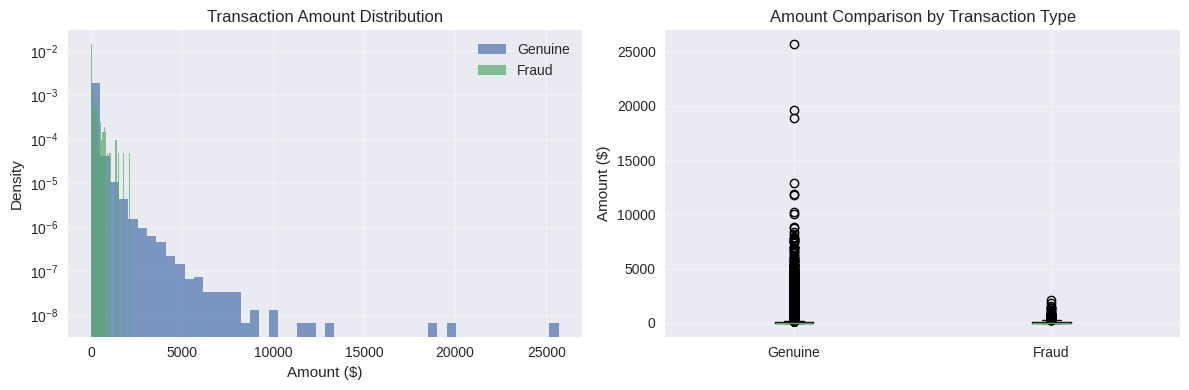

,Transaction Type,Mean Amount ($),Median Amount ($),Std Dev ($)
0,Genuine,88.29,22.00,250.11
1,Fraud,122.21,9.25,256.68


In [22]:

legitimate_amounts = transaction_data[transaction_data['Class'] == 0]['Amount']
fraudulent_amounts = transaction_data[transaction_data['Class'] == 1]['Amount']

fig, axes = visualizer.subplots(1, 2, figsize=(12, 4))

axes[0].hist(legitimate_amounts, bins=50, alpha=0.7, label='Genuine', density=True)
axes[0].hist(fraudulent_amounts, bins=50, alpha=0.7, label='Fraud', density=True)
axes[0].set_title('Transaction Amount Distribution')
axes[0].set_xlabel('Amount ($)')
axes[0].set_ylabel('Density')
axes[0].legend()
axes[0].set_yscale('log')
axes[0].grid(alpha=0.3)

axes[1].boxplot([legitimate_amounts, fraudulent_amounts], tick_labels=['Genuine', 'Fraud'])
axes[1].set_title('Amount Comparison by Transaction Type')
axes[1].set_ylabel('Amount ($)')
axes[1].grid(alpha=0.3)

visualizer.tight_layout()
visualizer.show()

data_processor.DataFrame({
    'Transaction Type': ['Genuine', 'Fraud'],
    'Mean Amount ($)': [legitimate_amounts.mean(), fraudulent_amounts.mean()],
    'Median Amount ($)': [legitimate_amounts.median(), fraudulent_amounts.median()],
    'Std Dev ($)': [legitimate_amounts.std(), fraudulent_amounts.std()]
}).round(2)

### Correlation with Target

In [23]:

feature_correlations = transaction_data.corr()['Class'].drop('Class').abs().sort_values(ascending=False)

data_processor.DataFrame({
    'Feature': feature_correlations.head(5).index,
    'Absolute Correlation': feature_correlations.head(5).round(4).values
})

,Feature,Absolute Correlation
0,V17,0.3265
1,V14,0.3025
2,V12,0.2606
3,V10,0.2169
4,V16,0.1965


Result: V17, V14, V12, V10 show strongest correlation with fraud.

## 4. Data Preprocessing

### Deleting Duplicate

In [24]:
records_before = len(transaction_data)
transaction_data = transaction_data.drop_duplicates()
records_after = len(transaction_data)

data_processor.DataFrame({
    'Stage': ['Before Removal', 'After Removal', 'Removed'],
    'Row Count': [records_before, records_after, records_before - records_after]
})

,Stage,Row Count
0,Before Removal,284807
1,After Removal,283726
2,Removed,1081


### Feature Scaling


The PCA features (V1–V28) are already scaled. However, Time and Amount have different ranges. I apply StandardScaler to bring them to a similar scale.

In [25]:

feature_scaler = StandardScaler()

input_features = transaction_data.drop('Class', axis=1).copy()
target_labels = transaction_data['Class']

input_features[['Time', 'Amount']] = feature_scaler.fit_transform(input_features[['Time', 'Amount']])

data_processor.DataFrame({
    'Feature': ['Time', 'Amount'],
    'After Scaling - Mean': [input_features['Time'].mean(), input_features['Amount'].mean()],
    'After Scaling - Std': [input_features['Time'].std(), input_features['Amount'].std()]
}).round(4)

,Feature,After Scaling - Mean,After Scaling - Std
0,Time,0.0,1.0
1,Amount,-0.0,1.0


## 5. Split Data

I split the data into training (80%) and testing (20%) sets, using stratification to maintain the same fraud ratio in both sets.

In [26]:

features_train, features_test, labels_train, labels_test = train_test_split(
    input_features, target_labels, test_size=0.2, random_state=42, stratify=target_labels
)


data_processor.DataFrame({
    'Dataset': ['Training Set', 'Testing Set'],
    'Total Transactions': [len(features_train), len(features_test)],
    'Fraud Cases': [labels_train.sum(), labels_test.sum()],
    'Fraud Percentage': [f"{labels_train.sum()/len(labels_train)*100:.3f}%",
                          f"{labels_test.sum()/len(labels_test)*100:.3f}%"]
})

,Dataset,Total Transactions,Fraud Cases,Fraud Percentage
0,Training Set,226980,378,0.167%
1,Testing Set,56746,95,0.167%


### Handle Class Imbalance

Since fraud cases are only 0.17%, I use two approaches:

1. class_weight='balanced' in models

2. Random oversampling of fraud cases in training data

In [28]:
train_combined = features_train.copy()
train_combined['Class'] = labels_train

fraud_cases = train_combined[train_combined['Class'] == 1]
genuine_cases = train_combined[train_combined['Class'] == 0]

before_balance = data_processor.DataFrame({
    'Class': ['Genuine', 'Fraud'],
    'Count': [len(genuine_cases), len(fraud_cases)],
    'Percentage': [f"{len(genuine_cases)/len(train_combined)*100:.2f}%",
                    f"{len(fraud_cases)/len(train_combined)*100:.2f}%"]
})

print("Before Balancing:")
display(before_balance)

fraud_oversampled = resample(fraud_cases, replace=True,
                             n_samples=len(genuine_cases), random_state=42)

balanced_training = data_processor.concat([genuine_cases, fraud_oversampled])
features_train_balanced = balanced_training.drop('Class', axis=1)
labels_train_balanced = balanced_training['Class']

after_balance = data_processor.DataFrame({
    'Class': ['Genuine', 'Fraud'],
    'Count': [len(genuine_cases), len(fraud_oversampled)],
    'Percentage': [f"{len(genuine_cases)/len(balanced_training)*100:.2f}%",
                    f"{len(fraud_oversampled)/len(balanced_training)*100:.2f}%"]
})

print("\nAfter Balancing (Oversampling):")
display(after_balance)

Before Balancing:


,Class,Count,Percentage
0,Genuine,226602,99.83%
1,Fraud,378,0.17%



After Balancing (Oversampling):


,Class,Count,Percentage
0,Genuine,226602,50.00%
1,Fraud,226602,50.00%


## 6. Train Models


I trained three models:

Model 1: Logistic Regression which is simple, interpretable and has good baseline model

Model 2: Decision Tree which captures non-linear relationships and it is  easy to understand

Model 3: Random Forest which is Ensemble of decision trees and usually more accurate and robust

In [30]:


classifiers = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced'),
    'Decision Tree': DecisionTreeClassifier(random_state=42, class_weight='balanced'),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced', n_jobs=-1)
}

trained_models = {}
training_results = []

for name, classifier in classifiers.items():
    classifier.fit(features_train_balanced, labels_train_balanced)
    trained_models[name] = classifier
    training_results.append({'Model': name, 'Status': 'Trained Successfully'})


print("Model Training Status:")
data_processor.DataFrame(training_results)

Model Training Status:


,Model,Status
0,Logistic Regression,Trained Successfully
1,Decision Tree,Trained Successfully
2,Random Forest,Trained Successfully



## 7. Evaluate Results

In [31]:
def evaluate_classifier(name, classifier, test_features, test_labels):

    predictions = classifier.predict(test_features)
    probabilities = classifier.predict_proba(test_features)[:, 1]

    return {
        'Model': name,
        'Accuracy': accuracy_score(test_labels, predictions),
        'Precision': precision_score(test_labels, predictions),
        'Recall': recall_score(test_labels, predictions),
        'F1-Score': f1_score(test_labels, predictions),
        'ROC-AUC': roc_auc_score(test_labels, probabilities),
        'PR-AUC': average_precision_score(test_labels, probabilities)
    }

In [32]:

performance_metrics = []

for name, classifier in trained_models.items():
    metrics = evaluate_classifier(name, classifier, features_test, labels_test)
    performance_metrics.append(metrics)

metrics_table = data_processor.DataFrame(performance_metrics).set_index('Model').round(4)

print("Model Performance Comparison:")
metrics_table

Model Performance Comparison:


,Accuracy,Precision,Recall,F1-Score,ROC-AUC,PR-AUC
Model,,,,,,
Logistic Regression,0.9755,0.0568,0.8737,0.1066,0.9661,0.6720
Decision Tree,0.9990,0.7531,0.6421,0.6932,0.8209,0.4842
Random Forest,0.9995,0.9714,0.7158,0.8242,0.9398,0.7926


In [33]:

best_model_name = metrics_table['F1-Score'].idxmax()
best_f1_score = metrics_table.loc[best_model_name, 'F1-Score']


data_processor.DataFrame({
    'Metric': ['Best Model', 'Best F1-Score', 'Precision', 'Recall', 'PR-AUC'],
    'Value': [
        best_model_name,
        f"{best_f1_score:.4f}",
        f"{metrics_table.loc[best_model_name, 'Precision']:.4f}",
        f"{metrics_table.loc[best_model_name, 'Recall']:.4f}",
        f"{metrics_table.loc[best_model_name, 'PR-AUC']:.4f}"
    ]
})

,Metric,Value
0,Best Model,Random Forest
1,Best F1-Score,0.8242
2,Precision,0.9714
3,Recall,0.7158
4,PR-AUC,0.7926


### Visual Comparison

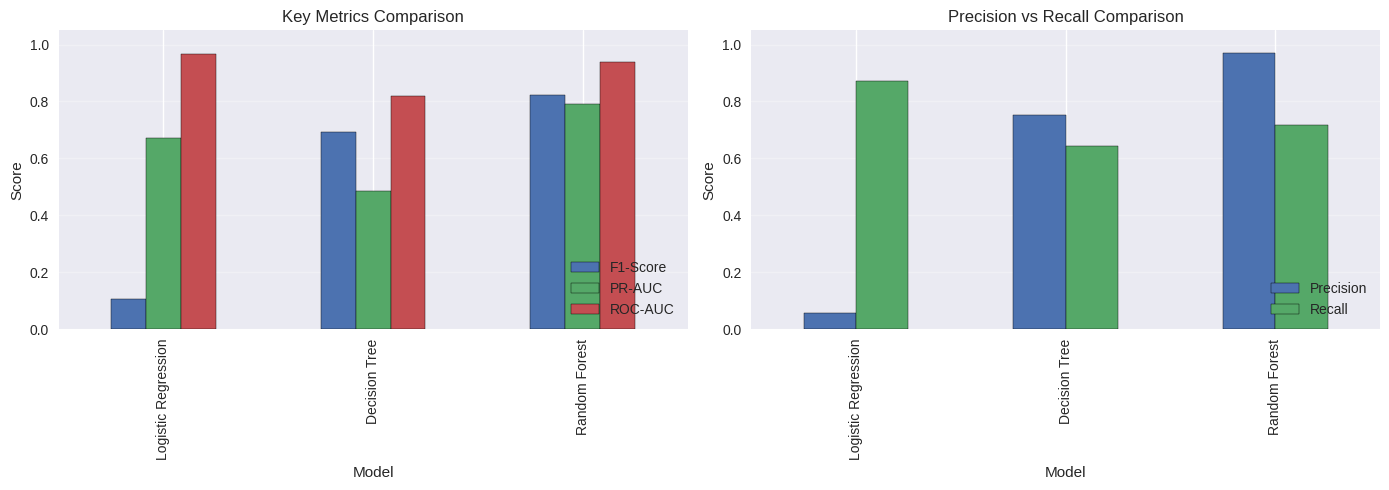

In [34]:

fig, axes = visualizer.subplots(1, 2, figsize=(14, 5))


metrics_table[['F1-Score', 'PR-AUC', 'ROC-AUC']].plot(
    kind='bar', ax=axes[0], edgecolor='black'
)
axes[0].set_title('Key Metrics Comparison', fontsize=12)
axes[0].set_ylabel('Score')
axes[0].set_ylim(0, 1.05)
axes[0].legend(loc='lower right')
axes[0].grid(axis='y', alpha=0.3)


metrics_table[['Precision', 'Recall']].plot(
    kind='bar', ax=axes[1], edgecolor='black'
)
axes[1].set_title('Precision vs Recall Comparison', fontsize=12)
axes[1].set_ylabel('Score')
axes[1].set_ylim(0, 1.05)
axes[1].legend(loc='lower right')
axes[1].grid(axis='y', alpha=0.3)

visualizer.tight_layout()
visualizer.show()

In [35]:

data_processor.DataFrame({
    'Metric': [
        'Dataset Loaded',
        'Duplicates Removed',
        'Features Scaled',
        'Train/Test Split',
        'Balanced Training Set',
        'Models Trained',
        'Best Model',
        'Best F1-Score',
        'Best PR-AUC'
    ],
    'Value': [
        f"{transaction_data.shape[0]:,} rows, {transaction_data.shape[1]} columns",
        f"{records_before - records_after:,} rows",
        "Time and Amount (StandardScaler)",
        f"{len(features_train):,} train / {len(features_test):,} test",
        f"{len(features_train_balanced):,} rows",
        f"{len(trained_models)} models",
        best_model_name,
        f"{best_f1_score:.4f}",
        f"{metrics_table.loc[best_model_name, 'PR-AUC']:.4f}"
    ]
})

,Metric,Value
0,Dataset Loaded,"283,726 rows, 31 columns"
1,Duplicates Removed,"1,081 rows"
2,Features Scaled,Time and Amount (StandardScaler)
3,Train/Test Split,"226,980 train / 56,746 test"
4,Balanced Training Set,"453,204 rows"
5,Models Trained,3 models
6,Best Model,Random Forest
7,Best F1-Score,0.8242
8,Best PR-AUC,0.7926


## 8. Conclusion

### Which Model Performed Best?

**Random Forest** achieved the best overall performance:

F1-Score: 0.8242 (highest among all models)

Precision: 0.9714 (when it predicts fraud, it's correct 97% of the time)

Recall: 0.7158 (catches about 72% of actual fraud cases)

PR-AUC: 0.7926 (best for imbalanced data)



### Why Random Forest?
Random Forest combines multiple decision trees, which helps:

Reduce overfitting compared to a single decision tree

Handle non-linear patterns in the data

Provide better generalization to new transactions

### What I Learned
Class imbalance is critical: Accuracy alone is misleading when fraud is only 0.17%. F1-Score and PR-AUC are better metrics.

Feature scaling matters: Even for tree-based models, consistent preprocessing helps.

Oversampling helps: Balancing the training data improved the model's ability to detect fraud.

Random Forest > Single Tree: The ensemble approach performed much better than a single decision tree.

Business Implications
High Precision means fewer legitimate transactions will be wrongly blocked, keeping customers happy

Good Recall means catching a significant portion of fraud, reducing financial losses

The model can be deployed for real-time fraud detection

### 9. References


1. Kaggle. (n.d.). Credit Card Fraud Detection Dataset. Retrieved from https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud

2. Scikit-learn. (n.d.). Machine Learning in Python. Retrieved from https://scikit-learn.org

3. Dal Pozzolo, A., et al. (2015). Credit Card Fraud Detection: A Realistic Modeling and a Novel Learning Strategy. IEEE Transactions on Neural Networks and Learning Systems.

4. Nilson Report. (2024). Card Fraud Losses Reach $33 Billion. Issue 1234.

